# Sec. 7.2: the verified backend on Gillian's queries

Gillian, run with `--certified-smt`, sends every SMT query to its own encoder
and, through a bridge into CSE's expression syntax, to the encoder extracted
from the Rocq development. `run.sh` runs 32 verification cases this way and
records each query in `queries.jsonl` (see `README.md`).

This notebook reads one such run. By default it reads the paper's (`paper-run/`);
to read your own re-run, set `RUN = "results"` below. The paper's numbers alone
are printed by `python report.py`.

1. Coverage and agreement (the paper's Fig. 9 table)
2. Solver time (the paper's Fig. 9 scatter plot, and the timings in its Appendix D)
3. The disagreements
4. What does not reach an answer

In [1]:
import json
import re
import shutil
import statistics
import subprocess
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

import report

RUN = "paper-run"
df, cases, records = report.load_run(RUN)
print(f"{RUN}: {len(df)} queries from {len(cases)} cases")

paper-run: 5820 queries from 32 cases


## 1. Coverage and agreement

A query passes through three stages on the verified side, and each column
counts the queries that passed that stage:

- **translated**: the bridge expressed it in CSE's syntax. Gillian's expression
  language is larger than CSE's; section 4 of this notebook shows what is left out.
- **encoded**: the extracted encoder produced SMT-LIB for it.
- **answered**: both backends' solver calls returned `sat` or `unsat`.

**agree** counts the answered queries on which the two backends gave the same
answer.

In [2]:
cov = report.coverage_table(df, cases)
cov["translated %"] = (100 * cov.translated / cov.queries).round(1)
cov["agree %"] = (100 * cov.agree / cov.answered).round(1)
cov

,files,queries,translated,encoded,answered,agree,translated %,agree %
language,,,,,,,,
JS,16,1324,985,937,937,923,74.4,98.5
C,7,4073,2989,2989,2988,2988,73.4,100.0
WISL,9,423,416,416,416,416,98.3,100.0
Total,32,5820,4390,4342,4341,4327,75.4,99.7


## 2. Solver time

Check-sat time only, for each query both backends answered: it excludes
building the query and sending the declarations and assertions. Points on the
dashed line took the same time under both encodings.

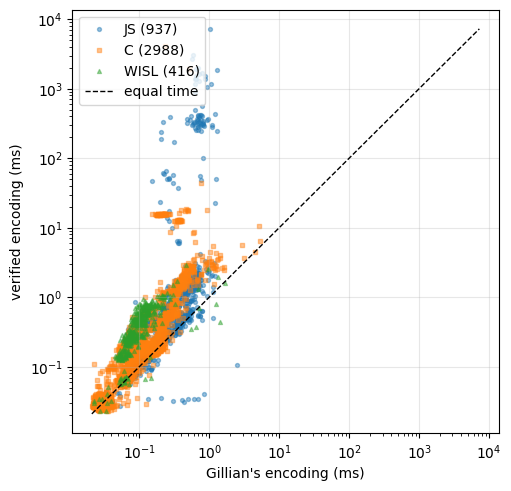

Gillian ms       verified ms        
             median   p95      median     p95
language                                     
JS             0.25  0.77        0.47  311.59
C              0.07  0.42        0.14    2.29
WISL           0.09  0.22        0.40    0.96
Total          0.09  0.59        0.16    2.68

In [3]:
a = df[df.answered]
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for lang, marker in [("JS", "o"), ("C", "s"), ("WISL", "^")]:
    d = a[a.language == lang]
    ax.scatter(d.u_ms, d.v_ms, s=8, alpha=0.45, marker=marker, label=f"{lang} ({len(d)})")
lo, hi = a[["u_ms", "v_ms"]].min().min(), a[["u_ms", "v_ms"]].max().max()
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="equal time")
ax.set(xscale="log", yscale="log", xlabel="Gillian's encoding (ms)", ylabel="verified encoding (ms)")
ax.legend(loc="upper left")
ax.grid(True, which="major", alpha=0.3)
plt.show()

report.timing_table(df).round(2)

In [4]:
# The slowest verified solver calls, and what Gillian's encoding took on the same query.
a.sort_values("v_ms", ascending=False).head(10)[["language", "command", "query_id", "u_ms", "v_ms", "u_sat"]]

,language,command,query_id,u_ms,v_ms,u_sat
854,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,460,1.014948,7258.265972,sat
3058,C,verify ./Gillian-C/examples/amazon/header.c ./...,653,0.232935,4086.747885,sat
807,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,413,0.587940,3039.151907,sat
850,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,456,0.569105,2703.078032,sat
882,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,488,0.697136,1974.838018,sat
3060,C,verify ./Gillian-C/examples/amazon/header.c ./...,655,0.514030,1925.864935,sat
889,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,495,0.641108,1924.970150,sat
911,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,517,1.271009,1868.575096,sat
862,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,468,0.800133,1704.471111,sat
869,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,475,0.707150,1644.989014,sat


### The slow tail

The medians are close, but a few queries take far longer under the verified
encoding: all from the two Amazon case studies, all `sat`, and all combining a
list's length with an operator added to CSE since the submitted paper (a cast
between integers and numbers, or a multiplication). Before those operators, the
bridge could not translate these queries, so the submitted paper's experiment
never sent them to the verified encoder.

In [5]:
TAIL_MS = 100
new_ops = {"IsInt": "cast", "NumToInt": "cast", "IntToNum": "cast",
           "ITimes": "multiplication", "FTimes": "multiplication",
           "LstCat": "concatenation", "LstNth": "indexing"}

def uses(i, op):
    return f'["{op}"]' in json.dumps(records[i]["expressions"])

tail = a[a.v_ms > TAIL_MS]
print(f"{len(tail)} of {len(a)} answered queries take over {TAIL_MS} ms with the verified encoding "
      f"(max {tail.v_ms.max():.0f} ms); Gillian's encoding takes at most {tail.u_ms.max():.1f} ms on them")
print("by case:", dict(Counter(tail.command.str.extract(r"(\S+\.(?:js|c|wisl))")[0])))
print("answers:", dict(Counter(tail.v_sat)))
print("using list length:", sum(uses(i, "LstLen") for i in tail.idx))
print("using an operator added since the submitted paper:",
      sum(any(uses(i, op) for op in new_ops) for i in tail.idx),
      dict(Counter(kind for i in tail.idx for kind in {new_ops[op] for op in new_ops if uses(i, op)})))

67 of 4341 answered queries take over 100 ms with the verified encoding (max 7258 ms); Gillian's encoding takes at most 1.3 ms on them
by case: {'./Gillian-JS/Examples/Amazon/deserialize_factory.js': 65, './Gillian-C/examples/amazon/header.c': 2}
answers: {'sat': 67}
using list length: 67
using an operator added since the submitted paper: 67 {'cast': 65, 'multiplication': 61}


The difference is in how the two encoders encode a list's length.

- **The verified encoder** encodes it exactly, as `seq.len` of an SMT-LIB
  sequence. To answer `sat`, Z3 must then build the lists: in the slowest
  query, `96 * len(c) = len(l)` with `len(c) >= 1` makes it construct a list
  of at least 96 values.
- **Gillian's encoder** abstracts it (`GillianCore/smt/smt.ml`, `encode_unop`):
  a list variable that appears only under length gets an uninterpreted
  length, `l-len(x)`, and no list is ever built.

Gillian's abstraction is equisatisfiable when the query also says
`0 <= l-len(x)` and no such list is bound by a quantifier. Both hold for every
query in this run, but Gillian's symbolic engine guarantees them, not its
encoder. Without them, an abstracted query can be `sat` when the real one is
not, which an under-approximate (UX) analysis must not allow. An `unsat` is
always right.

The check: apply Gillian's abstraction to the tail's verified queries, solve
them again, and compare. Each solve starts a fresh `z3`, whose start-up time
the first line measures. Needs `z3` on the `PATH`.

In [6]:
import time

def solve(commands):
    query = "\n".join(c for c in commands if c.strip() != "check-sat") + "\n(check-sat)\n"
    start = time.time()
    out = subprocess.run(["z3", "-in", "-T:60"], input=query, capture_output=True, text=True).stdout.split()
    return 1000 * (time.time() - start), (out[-1] if out else "no answer")

def abstract_lengths(commands):
    """Gillian's abstraction: a sequence used only under seq.len gets a fresh
    integer length, at least 0."""
    text = "\n".join(commands)
    lists = re.findall(r"\(declare-const (\S+) \(Seq", text)
    def occurrences(x): return len(re.findall(re.escape(x) + r"(?=[\s)])", text))
    def under_len(x): return len(re.findall(r"\(seq\.len\s+" + re.escape(x) + r"\)", text))
    only_len = [x for x in lists if occurrences(x) - 1 == under_len(x)]
    out = []
    for c in commands:
        for x in only_len:
            c = re.sub(r"\(seq\.len\s+" + re.escape(x) + r"\)", f"len{x}", c)
            if c.startswith(f"(declare-const {x} "):
                c = f"(declare-const len{x} Int)\n(assert (<= 0 len{x}))"
        out.append(c)
    return out

if shutil.which("z3") is None:
    print("z3 is not on the PATH")
else:
    startup = statistics.median(solve([])[0] for _ in range(5))
    print(f"z3 start-up and an empty check-sat: {startup:.1f} ms")
    exact, abstracted, same = [], [], 0
    for i in tail.idx:
        commands = records[i]["verified"]["smt_query"]
        t1, r1 = solve(commands)
        t2, r2 = solve(abstract_lengths(commands))
        exact.append(t1); abstracted.append(t2); same += r1 == r2
    print(f"the {len(tail)} tail queries, solved again (ms, median / max):")
    print(f"  as the verified encoder wrote them:   {statistics.median(exact):8.1f} / {max(exact):8.1f}")
    print(f"  with Gillian's length abstraction:    {statistics.median(abstracted):8.1f} / {max(abstracted):8.1f}")
    print(f"  same answer: {same} of {len(tail)}")

z3 start-up and an empty check-sat: 9.7 ms


the 67 tail queries, solved again (ms, median / max):
  as the verified encoder wrote them:      166.2 /   3755.7
  with Gillian's length abstraction:        19.3 /     27.8
  same answer: 67 of 67


## 3. The disagreements

Every disagreement is `sat` from Gillian and `unsat` from the verified encoder,
on a query that uses `IntToNum`, Gillian's integer-to-number cast, which the
bridge translates to CSE's `NatToRat`.

The cause is a difference between the languages, not between the encodings.
CSE's numbers are `Qp`, the strictly positive rationals, so `NatToRat` is
undefined at 0 (`theories/LogicalExpression.v`):

```coq
| (Op1NatToRat, pVNat 0) => None
| (Op1NatToRat, pVNat (S m)) => Some $ VRat $ pos_to_Qp (Pos.of_succ_nat m)
```

and the verified encoder's encoding of `NatToRat(n)` carries the side condition
`0 < n` (`cse_smtlib_theories/Encoding.v`). Gillian's `IntToNum(0)` is `0`. A
query that forces such an `n` to be 0, literally (`IntToNum(0)` encodes to
`(assert (< 0 0))`) or through its constraints (an empty list's length), is
satisfiable in Gillian's semantics and unsatisfiable in CSE's.

In [7]:
dis = df[df.answered & ~df.agree]
print(f"{len(dis)} disagreements; {int(dis.uses_int_to_num.sum())} use IntToNum")
dis[["language", "command", "query_id", "u_sat", "v_sat"]]

14 disagreements; 14 use IntToNum


,language,command,query_id,u_sat,v_sat
515,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,121,sat,unsat
517,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,123,sat,unsat
518,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,124,sat,unsat
731,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,337,sat,unsat
744,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,350,sat,unsat
757,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,363,sat,unsat
774,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,380,sat,unsat
1095,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,701,sat,unsat
1121,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,727,sat,unsat
1122,JS,verify ./Gillian-JS/Examples/Amazon/deserializ...,728,sat,unsat


In [8]:
# One of them: Gillian's expressions, then the verified encoder's query.
r = records[dis.idx.iloc[0]]
for e in r["expressions"]:
    print(json.dumps(e))
print()
print("\n".join(r["verified"]["smt_query"]))

["UnOp", ["IsInt"], ["LVar", "#esLength"]]
["UnOp", ["IsInt"], ["LVar", "#fCount"]]
["UnOp", ["IsInt"], ["LVar", "#readPos"]]
["BinOp", ["Lit", ["Int", "0"]], ["ILessThanEqual"], ["UnOp", ["LstLen"], ["LVar", "#buffer"]]]
["BinOp", ["Lit", ["Int", "0"]], ["ILessThanEqual"], ["UnOp", ["LstLen"], ["LVar", "#suffix"]]]
["BinOp", ["Lit", ["Num", 0.0]], ["FLessThan"], ["LVar", "#fCount"]]
["BinOp", ["Lit", ["Num", 0.0]], ["FLessThanEqual"], ["LVar", "#esLength"]]
["BinOp", ["Lit", ["Num", 0.0]], ["FLessThanEqual"], ["LVar", "#readPos"]]
["BinOp", ["Lit", ["Num", 0.0]], ["FLessThanEqual"], ["BinOp", ["Lit", ["Num", 1.0]], ["FPlus"], ["BinOp", ["UnOp", ["IntToNum"], ["Lit", ["Int", "0"]]], ["FPlus"], ["UnOp", ["IntToNum"], ["UnOp", ["LstLen"], ["LVar", "#suffix"]]]]]]
["BinOp", ["BinOp", ["LVar", "#esLength"], ["FPlus"], ["LVar", "#readPos"]], ["FLessThanEqual"], ["UnOp", ["IntToNum"], ["UnOp", ["LstLen"], ["LVar", "#buffer"]]]]

(declare-datatype Null ((null)))
(declare-datatype
 Val
 ((null

The check: drop from each disagreeing query the side conditions `0 < n` that
its `NatToRat`s add (each `n` appears as `(to_real n)`), and solve it again.
If the side conditions are the whole difference, every query becomes `sat`,
Gillian's answer. Needs `z3` on the `PATH`.

In [9]:
def without_as_num_side_conditions(commands):
    args = {" ".join(m.split()) for m in re.findall(r"\(to_real\s+(\([^()]*\)|[^\s()]+)\)", "\n".join(commands))}
    def side_condition(c):
        m = re.fullmatch(r"\(assert\s+\(<\s+0\s+(.*)\)\)", " ".join(c.split()))
        return m and (m.group(1) in args or m.group(1) == "0")
    return [c for c in commands if not side_condition(c) and c.strip() != "check-sat"]

if shutil.which("z3") is None:
    print("z3 is not on the PATH")
else:
    answers = Counter()
    for i in dis.idx:
        query = "\n".join(without_as_num_side_conditions(records[i]["verified"]["smt_query"])) + "\n(check-sat)\n"
        out = subprocess.run(["z3", "-in"], input=query, capture_output=True, text=True, timeout=60).stdout.split()
        answers[out[-1] if out else "no answer"] += 1
    print("without the NatToRat side conditions:", dict(answers))

without the NatToRat side conditions: {'sat': 14}


In [10]:
# Among the answered queries that do not use IntToNum, no disagreement.
rest = df[df.answered & ~df.uses_int_to_num]
print(f"{int((~rest.agree).sum())} disagreements among {len(rest)} answered queries without IntToNum")

0 disagreements among 3911 answered queries without IntToNum


### What the bridge does not send: representability guards

The paper's satisfiability check (its Sec. 6) also asserts *representability
guards*: one per free variable, saying its value is one CSE has, so that a
`sat` answer's model is a CSE model. The bridge sends the encoded expressions
and their side conditions, but not the guards. Gillian's numbers include 0 and
the negatives, which CSE's do not, so with the guards the comparison would
measure that difference between the languages rather than the encoders.
Omitting assertions weakens a query: an `unsat` without the guards is still
`unsat` with them, and only a `sat` answer can be a model CSE does not have.

For the same reason, the bridge translates Gillian's number literals that are
not positive, almost always `0.`, although CSE has no such number: the encoder
handles them as it handles any rational, and the comparison then uses Gillian's
meaning of them. Negative *integer* literals are different: CSE's integers are
naturals, the extracted encoder cannot represent a negative one, and the bridge
leaves those queries untranslated.

## 4. What does not reach an answer

By stage and language:

In [11]:
pd.crosstab(df.language, df.stage).reindex(columns=report.STAGES).reindex(report.LANGUAGES)

stage,not translated,not encoded,not answered,answered
language,,,,
JS,339,48,0,937
C,1084,0,1,2988
WISL,7,0,0,416


**Not translated.** The bridge reports, for each expression it cannot
translate, the path to the sub-expression that stopped it (`left operand
failed: ...`). Grouped by that sub-expression, per query:

In [12]:
def root_cause(failure):
    reason = failure.get("reason", "")
    # The innermost failure: drop the path down to it.
    return reason.split(" failed: ")[-1].split(":")[0]

causes = Counter()
for r, lang in zip(records, df.language):
    for cause in {root_cause(f) for f in r["verified"]["coercion_failures"]}:
        causes[(lang, cause)] += 1
(pd.Series(causes, name="queries").rename_axis(["language", "cause"])
   .reset_index().sort_values(["language", "queries"], ascending=[True, False])
   .reset_index(drop=True))

,language,cause,queries
0,C,unsupported negative integer literal -256,719
1,C,unsupported negative integer literal -1,674
2,C,unsupported negative integer literal -96,177
3,C,unsupported universal quantifier,84
4,C,unsupported set expression,34
5,C,unsupported negative integer literal -4,32
6,C,unsupported binary operator -e-,23
7,C,unsupported list-sub expression,22
8,C,unsupported n-ary expression -u-,15
9,C,unsupported existential quantifier,10


Gillian's sets (`-e-` is set membership, `-u-` set union) and quantifiers have
no counterpart in CSE's expression language.

**Translated, but not answered**, by the first diagnostic. The verified
encoder declines (returns `None` for) an expression that is ill-typed in CSE,
such as Gillian's comparison of a list length, an integer, with a number
(`l-len #view < 22.`), which Z3 accepts by converting between the two.

In [13]:
lost = df[df.stage.isin(["not encoded", "not answered"])]
lost.groupby(["stage", "language", "reason"]).size().rename("queries").reset_index()

,stage,language,reason,queries
0,not encoded,JS,extracted encoder returned None,48
